In [89]:
import os
import re
import csv
import numpy as np
import pandas as pd
from ase.io import read
import matplotlib.pyplot as plt

# Show float values with 2 decimal places when displaying DataFrames.
pd.options.display.float_format = '{:.2f}'.format

# Ensure wide DataFrames print all columns (no truncation).
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', None)
pd.set_option('display.width', 20000)
pd.set_option('display.expand_frame_repr', True)

root = '/Users/jiuy97/Desktop/3_RuO2/6_ICOHP'
# root = '/Users/hailey/Desktop/3_RuO2/6_ICOHP/4_slab_M-RuO2'
# oxygen_potential = -4.658724749999999 # 300K
# oxygen_potential = -4.658724749999999+0.27-0.73 # 700K
oxygen_potential = -4.658724749999999+0.27-0.85 # 800K
figsize = (4, 3)
dpi = 300

In [90]:
data = pd.DataFrame()
subdirs = ['0_Ru', '1_Hf', '2_Ta', '3_W', '4_Re', '5_Os', '6_Ir', '7_Pt']
elements = ['Ru', 'Hf', 'Ta', 'W', 'Re', 'Os', 'Ir', 'Pt']

In [ ]:
# for dir in ['1_cus_V_V', '2_brg_V_V', '3_cus_O_O', '4_brg_O_O']:
for dir in ['1_cus_V_V', '2_brg_V_V']:
    ads_site = dir.split('_')[1]
    coverage = dir.split('_')[2]
    for e, element in enumerate(elements):
        path = os.path.join(root, '4_slab_M-RuO2', 'icohp', dir, f'{e}_{element}', 'icohp_sum.txt')
        if not os.path.isfile(path) or os.path.getsize(path) == 0:
            continue

        # icohp4.py 출력: 주석(#) / 데이터: ele idx n_bonds distance_avg sum_ICOHP
        try:
            df = pd.read_csv(
                path,
                sep=r"\s+",
                comment="#",
                header=None,
                names=["ele", "idx", "n_bonds", "distance_avg", "sum_ICOHP"],
            )
        except Exception:
            continue

        row_key = f"{ads_site}_{coverage}_{element}"
        for _, r in df.iterrows():
            try:
                i = int(r["idx"])
            except (TypeError, ValueError):
                continue
            if 1 <= i <= 16:
                data.loc[row_key, f"M{i-1}"] = float(r["sum_ICOHP"])

a = data.loc['brg_V_Ru', 'M13']
b = data.loc['brg_V_Ru', 'M15']
data.loc['brg_V_Ru', 'M13'] = b
data.loc['brg_V_Ru', 'M15'] = a

data['ICOHP_all'] = data[[col for col in data.columns if col.startswith('M')]].sum(axis=1) / 16
data['ICOHP_top'] = data[['M12', 'M13', 'M14', 'M15']].sum(axis=1) / 4
data


,M0,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11,M12,M13,M14,M15,ICOHP_all,ICOHP_top
cus_V_Ru,-9.93,-9.93,-12.24,-12.21,-11.57,-11.60,-11.68,-11.69,-11.50,-11.51,-11.59,-11.60,-12.37,-12.36,-10.64,-10.65,-11.44,-11.50
cus_V_Hf,-9.91,-9.92,-12.18,-12.18,-11.54,-11.54,-11.62,-11.59,-11.55,-11.54,-11.54,-11.54,-12.24,-12.24,-10.63,-13.50,-11.58,-12.15
cus_V_Ta,-9.94,-9.96,-12.12,-12.12,-11.50,-11.50,-11.62,-11.66,-11.52,-11.53,-11.47,-11.47,-12.08,-12.08,-9.02,-17.27,-11.68,-12.61
cus_V_W,-9.91,-9.91,-12.17,-12.17,-11.46,-11.46,-11.61,-11.66,-11.47,-11.53,-11.40,-11.40,-11.51,-11.51,-8.86,-18.89,-11.68,-12.69
cus_V_Os,-9.90,-9.92,-12.17,-12.17,-11.49,-11.49,-11.65,-11.66,-11.60,-11.62,-11.53,-11.53,-12.15,-12.15,-9.76,-14.08,-11.56,-12.04
cus_V_Ir,-9.90,-9.92,-12.19,-12.19,-11.61,-11.60,-11.68,-11.63,-11.66,-11.66,-11.64,-11.64,-12.13,-12.12,-10.78,-11.56,-11.49,-11.65
cus_V_Pt,-9.96,-9.98,-12.16,-12.15,-11.52,-11.52,-11.78,-11.68,-11.68,-11.63,-11.77,-11.77,-12.33,-12.33,-10.79,-8.71,-11.36,-11.04
brg_V_Ru,-9.93,-9.93,-12.24,-12.21,-11.57,-11.60,-11.67,-11.68,-11.48,-11.48,-11.56,-11.57,-12.35,-10.62,-10.61,-12.34,-11.43,-11.48
brg_V_Hf,-9.96,-9.97,-12.15,-12.14,-11.57,-11.56,-11.59,-11.59,-11.49,-11.49,-11.66,-11.65,-13.06,-10.72,-10.72,-14.01,-11.58,-12.13
brg_V_Ta,-9.92,-9.94,-12.23,-12.28,-11.59,-11.60,-11.63,-11.63,-11.48,-11.48,-11.69,-11.72,-11.10,-10.49,-10.50,-17.88,-11.70,-12.49


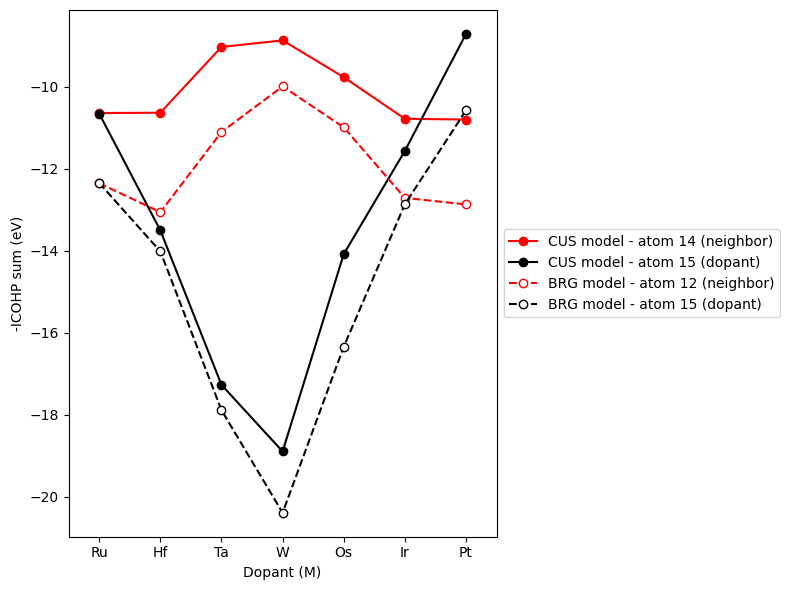

In [92]:
plt.figure(figsize=(8,6))
elements = ['Ru', 'Hf', 'Ta', 'W', 'Os', 'Ir', 'Pt']

# colors = ['silver', 'silver', 'black', 'black', 'black', 'black', 'black', 'black',
colors1 = ['silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver',
'tab:blue', 'tab:blue', 'tab:orange', 'tab:orange', 'tab:green', 'tab:green', 'red', 'black']
colors2 = ['silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver',
'tab:blue', 'tab:blue', 'tab:orange', 'tab:orange', 'red', 'tab:green', 'tab:green', 'black']

plt.plot(elements, data[f'M14'][0:7], marker='o', label='CUS model - atom 14 (neighbor)', color='red')
plt.plot(elements, data[f'M15'][0:7], marker='o', label='CUS model - atom 15 (dopant)', color='black')

plt.plot(elements, data[f'M12'][7:14], marker='o', markerfacecolor='white', linestyle='--', label='BRG model - atom 12 (neighbor)', color='red')
plt.plot(elements, data[f'M15'][7:14], marker='o', markerfacecolor='white', linestyle='--',label='BRG model - atom 15 (dopant)', color='black')
    
plt.xlabel('Dopant (M)')
plt.ylabel('-ICOHP sum (eV)')
# plt.ylim(1.0, 2.8)

plt.xlim(-0.5, 6.5)
# plt.xticks(range(len(elements)-1), elements-['Re'])
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.savefig(f'{root}/figures/bader_charge_per_atom1.png', dpi=dpi, transparent=True, bbox_inches='tight')
plt.tight_layout()
plt.show()
plt.close()

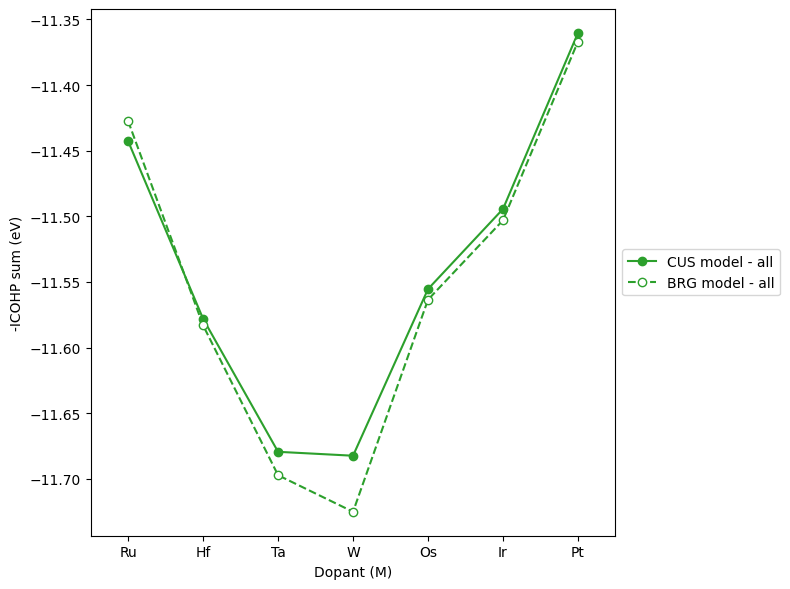

In [99]:
plt.figure(figsize=(8,6))
elements = ['Ru', 'Hf', 'Ta', 'W', 'Os', 'Ir', 'Pt']

# colors = ['silver', 'silver', 'black', 'black', 'black', 'black', 'black', 'black',
colors1 = ['silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver',
'tab:blue', 'tab:blue', 'tab:orange', 'tab:orange', 'tab:green', 'tab:green', 'red', 'black']
colors2 = ['silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver',
'tab:blue', 'tab:blue', 'tab:orange', 'tab:orange', 'red', 'tab:green', 'tab:green', 'black']

plt.plot(elements, data[f'ICOHP_all'][0:7], marker='o', label='CUS model - all', color='tab:green')
# plt.plot(elements, data[f'ICOHP_top'][0:7], marker='o', label='CUS model - top layer', color='tab:blue')

plt.plot(elements, data[f'ICOHP_all'][7:14], marker='o', markerfacecolor='white', linestyle='--', label='BRG model - all', color='tab:green')
# plt.plot(elements, data[f'ICOHP_top'][7:14], marker='o', markerfacecolor='white', linestyle='--', label='BRG model - top layer', color='tab:blue')

    
plt.xlabel('Dopant (M)')
plt.ylabel('-ICOHP sum (eV)')
# plt.ylim(1.0, 2.8)

plt.xlim(-0.5, 6.5)
# plt.xticks(range(len(elements)-1), elements-['Re'])
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.savefig(f'{root}/figures/bader_charge_per_atom1.png', dpi=dpi, transparent=True, bbox_inches='tight')
plt.tight_layout()
plt.show()
plt.close()

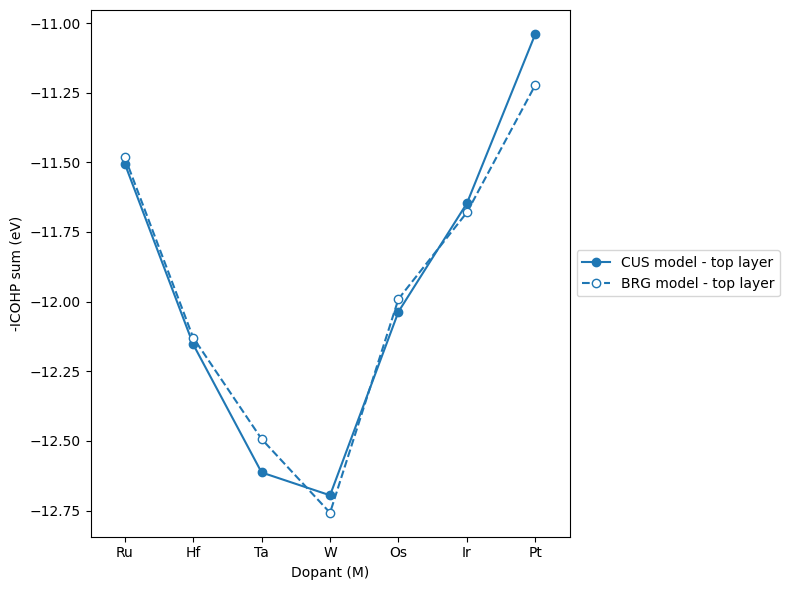

In [101]:
plt.figure(figsize=(8,6))
elements = ['Ru', 'Hf', 'Ta', 'W', 'Os', 'Ir', 'Pt']

# colors = ['silver', 'silver', 'black', 'black', 'black', 'black', 'black', 'black',
colors1 = ['silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver',
'tab:blue', 'tab:blue', 'tab:orange', 'tab:orange', 'tab:green', 'tab:green', 'red', 'black']
colors2 = ['silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver',
'tab:blue', 'tab:blue', 'tab:orange', 'tab:orange', 'red', 'tab:green', 'tab:green', 'black']

# plt.plot(elements, data[f'ICOHP_all'][0:7], marker='o', label='CUS model - all', color='tab:green')
plt.plot(elements, data[f'ICOHP_top'][0:7], marker='o', label='CUS model - top layer', color='tab:blue')

# plt.plot(elements, data[f'ICOHP_all'][7:14], marker='o', markerfacecolor='white', linestyle='--', label='BRG model - all', color='tab:green')
plt.plot(elements, data[f'ICOHP_top'][7:14], marker='o', markerfacecolor='white', linestyle='--', label='BRG model - top layer', color='tab:blue')

    
plt.xlabel('Dopant (M)')
plt.ylabel('-ICOHP sum (eV)')
# plt.ylim(1.0, 2.8)

plt.xlim(-0.5, 6.5)
# plt.xticks(range(len(elements)-1), elements-['Re'])
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.savefig(f'{root}/figures/bader_charge_per_atom1.png', dpi=dpi, transparent=True, bbox_inches='tight')
plt.tight_layout()
plt.show()
plt.close()

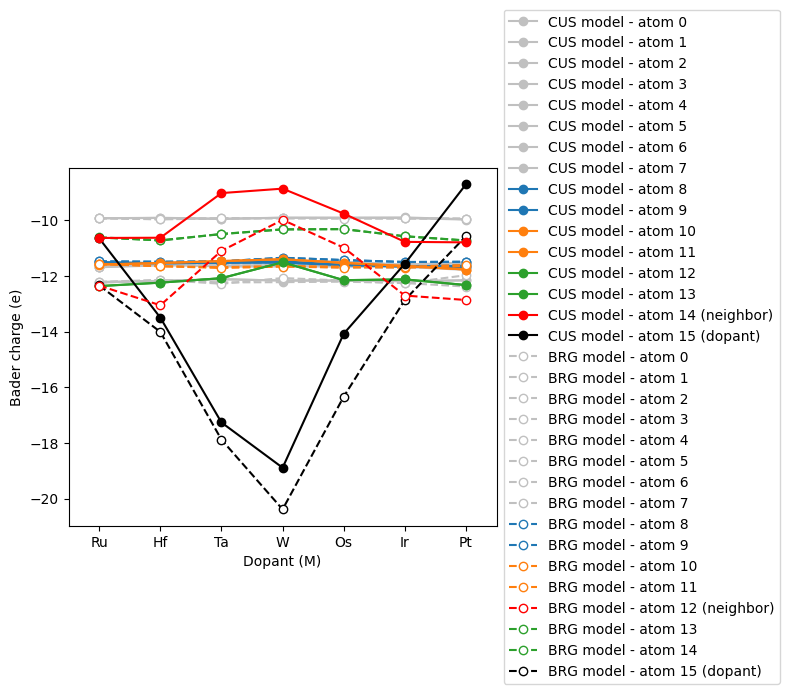

In [94]:
plt.figure(figsize=(8,6))
elements = ['Ru', 'Hf', 'Ta', 'W', 'Os', 'Ir', 'Pt']

# colors = ['silver', 'silver', 'black', 'black', 'black', 'black', 'black', 'black',
colors1 = ['silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver',
'tab:blue', 'tab:blue', 'tab:orange', 'tab:orange', 'tab:green', 'tab:green', 'red', 'black']
colors2 = ['silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver',
'tab:blue', 'tab:blue', 'tab:orange', 'tab:orange', 'red', 'tab:green', 'tab:green', 'black']

for i in range(0,16):
    zorder = i
    if i == 15:
        label = f'CUS model - atom {i} (dopant)'
    elif i == 14:
        label = f'CUS model - atom {i} (neighbor)'
        zorder = 16
    else:
        label = f'CUS model - atom {i}'
    plt.plot(
        elements, 
        data[f'M{i}'][0:7], 
        marker='o',
        label=label,
        color=colors1[i % len(colors1)],
        zorder=zorder
    )

for i in range(0,16):
    zorder = i
    if i == 15:
        label = f'BRG model - atom {i} (dopant)'
    elif i == 12:
        label = f'BRG model - atom {i} (neighbor)'
        zorder = 16
    else:
        label = f'BRG model - atom {i}'
    plt.plot(
        elements, 
        data[f'M{i}'][7:14], 
        linestyle='--',
        marker='o',
        label=label,
        color=colors2[i % len(colors2)],
        markerfacecolor='white',
        zorder=zorder
    )
    
plt.xlabel('Dopant (M)')
plt.ylabel('Bader charge (e)')
# plt.ylim(1.0, 2.8)

plt.xlim(-0.5, 6.5)
# plt.xticks(range(len(elements)-1), elements-['Re'])
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.savefig(f'{root}/figures/bader_charge_per_atom1.png', dpi=dpi, transparent=True, bbox_inches='tight')
plt.tight_layout()
plt.show()
plt.close()

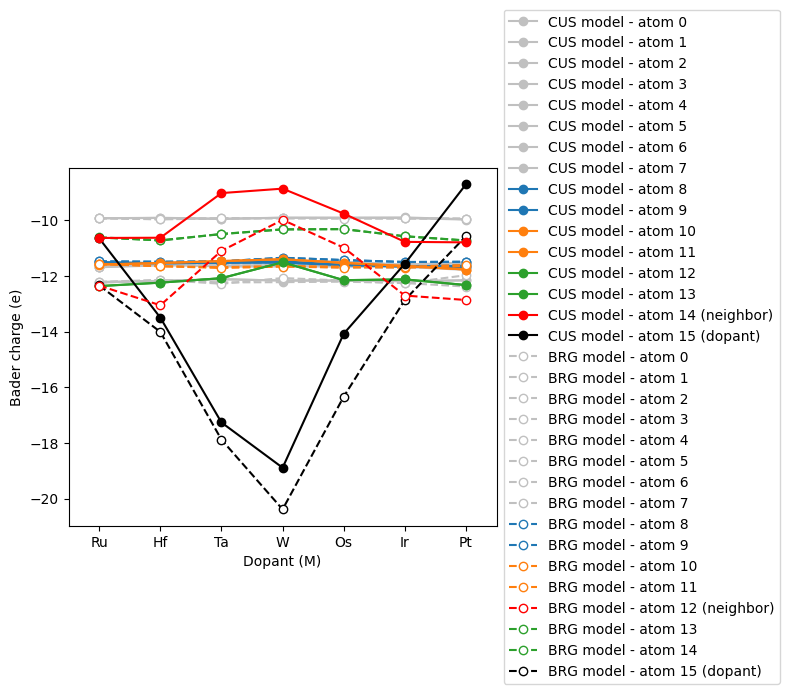

In [95]:
plt.figure(figsize=(8,6))
elements = ['Ru', 'Hf', 'Ta', 'W', 'Os', 'Ir', 'Pt']

# colors = ['silver', 'silver', 'black', 'black', 'black', 'black', 'black', 'black',
colors1 = ['silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver',
'tab:blue', 'tab:blue', 'tab:orange', 'tab:orange', 'tab:green', 'tab:green', 'red', 'black']
colors2 = ['silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver', 'silver',
'tab:blue', 'tab:blue', 'tab:orange', 'tab:orange', 'red', 'tab:green', 'tab:green', 'black']

for i in range(0,16):
    zorder = i
    if i == 15:
        label = f'CUS model - atom {i} (dopant)'
    elif i == 14:
        label = f'CUS model - atom {i} (neighbor)'
        zorder = 16
    else:
        label = f'CUS model - atom {i}'
    plt.plot(
        elements, 
        data[f'M{i}'][0:7], 
        marker='o',
        label=label,
        color=colors1[i % len(colors1)],
        zorder=zorder
    )

for i in range(0,16):
    zorder = i
    if i == 15:
        label = f'BRG model - atom {i} (dopant)'
    elif i == 12:
        label = f'BRG model - atom {i} (neighbor)'
        zorder = 16
    else:
        label = f'BRG model - atom {i}'
    plt.plot(
        elements, 
        data[f'M{i}'][7:14], 
        linestyle='--',
        marker='o',
        label=label,
        color=colors2[i % len(colors2)],
        markerfacecolor='white',
        zorder=zorder
    )
    
plt.xlabel('Dopant (M)')
plt.ylabel('Bader charge (e)')
# plt.ylim(1.0, 2.8)

plt.xlim(-0.5, 6.5)
# plt.xticks(range(len(elements)-1), elements-['Re'])
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.savefig(f'{root}/figures/bader_charge_per_atom1.png', dpi=dpi, transparent=True, bbox_inches='tight')
plt.tight_layout()
plt.show()
plt.close()

In [96]:
plt.figure(figsize=(8,6))

# colors = ['silver', 'silver', 'black', 'black', 'black', 'black', 'black', 'black',
colors1 = ['tab:orange', 'red', 'tab:green', 'tab:green', 'black', 'black', 'black', 'black', 'tab:blue', 'tab:blue']
colors2 = ['tab:green', 'tab:green', 'black', 'black', 'tab:blue', 'red', 'tab:blue', 'red', 'black', 'black']

for i in range(38,48):
    j = i - 38
    zorder = i
    if i == 39:
        label = f'CUS model - atom {i} (z)'
        zorder = 50
    elif i in [42, 43, 44, 45]:
        label = f'CUS model - atom {i} (xy)'
        zorder = 49
    else:
        label = f'CUS model - atom {i}'
    plt.plot(
        elements, 
        data[f'O{i}'][0:8], 
        marker='o',
        label=label,
        color=colors1[j % len(colors1)],
        zorder=zorder
    )

for i in range(38,48):
    j = i - 38
    zorder = i
    if i in [43, 45]:
        label = f'BRG model - atom {i} (z)'
        zorder = 50
    elif i in [40, 41, 46, 47]:
        label = f'BRG model - atom {i} (xy)'
        zorder = 49
    else:
        label = f'BRG model - atom {i}'
    plt.plot(
        elements, 
        data[f'O{i}'][8:16], 
        linestyle='--',
        marker='o',
        label=label,
        color=colors2[j % len(colors2)],
        markerfacecolor='white',
        zorder=zorder
    )
    
plt.xlabel('Dopant (M)')
plt.ylabel('Bader charge (e)')
plt.ylim(-1.3, -0.6)

plt.xlim(-0.5, 7.5)
plt.xticks(range(len(elements)), elements)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.savefig(f'{root}/figures/bader_charge_per_atom1.png', dpi=dpi, transparent=True, bbox_inches='tight')
plt.tight_layout()
plt.show()
plt.close()

KeyError: 'O38'

<Figure size 800x600 with 0 Axes>

In [ ]:
for dir in ['1_bulk_MO2', '2_bulk_MxOy']:
    oxide_type = dir.split('_')[2]
    for e, element in enumerate(elements):
        path = os.path.join(root, dir, f'{e}_{element}', 'atoms_bader_charge.json')
        if os.path.exists(path):
            atoms = read(path)
            chgs = atoms.get_initial_charges()
            metal_chgs = [chg for atom, chg in zip(atoms, chgs) if atom.symbol != 'O']
            oxygen_chgs = [chg for atom, chg in zip(atoms, chgs) if atom.symbol == 'O']
            chg_metal = sum(metal_chgs) / len(metal_chgs)
            chg_oxygen = sum(oxygen_chgs) / len(oxygen_chgs)
            for ads_site in ['cus', 'brg']:
                for coverage in ['V', 'O']:
                    data.loc[f'{ads_site}_{coverage}_{element}', f'{oxide_type}(M)'] = chg_metal
                    data.loc[f'{ads_site}_{coverage}_{element}', f'{oxide_type}(O)'] = chg_oxygen

for dir in ['3_bulk_M-RuO2']:
    oxide_type = dir.split('_')[2]
    for e, element in enumerate(elements):
        path = os.path.join(root, dir, f'{e}_{element}', 'atoms_bader_charge.json')
        if os.path.exists(path):
            atoms = read(path)
            chgs = atoms.get_initial_charges()
            M_index = [7]
            Ru_index = [0, 1, 2, 3, 4, 5, 6]
            O_index = [8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]
            M_chg = sum(chgs[M_index])/len(M_index)
            Ru_chg = sum(chgs[Ru_index])/len(Ru_index)
            O_chg = sum(chgs[O_index])/len(O_index)
            for ads_site in ['cus', 'brg']:
                for coverage in ['V', 'O']:
                    data.loc[f'{ads_site}_{coverage}_{element}', f'{oxide_type}(M)'] = M_chg
                    data.loc[f'{ads_site}_{coverage}_{element}', f'{oxide_type}(Ru)'] = Ru_chg
                    data.loc[f'{ads_site}_{coverage}_{element}', f'{oxide_type}(O)'] = O_chg

data

,M0,M1,M2,M3,M4,M5,M6,M7,M8,M9,M10,M11,M12,M13,M14,M15,O16,O17,O18,O19,O20,O21,O22,O23,O24,O25,O26,O27,O28,O29,O30,O31,O32,O33,O34,O35,O36,O37,O38,O39,O40,O41,O42,O43,O44,O45,O46,O47,MO2(M),MO2(O),MxOy(M),MxOy(O),M-RuO2(M),M-RuO2(Ru),M-RuO2(O)
cus_V_Ru,1.62,1.62,1.73,1.73,1.72,1.72,1.71,1.71,1.72,1.72,1.63,1.63,1.76,1.76,1.68,1.68,-0.80,-0.80,-0.87,-0.87,-0.87,-0.87,-0.82,-0.82,-0.83,-0.83,-0.87,-0.87,-0.87,-0.87,-0.87,-0.87,-0.82,-0.82,-0.87,-0.87,-0.87,-0.87,-0.86,-0.86,-0.84,-0.84,-0.87,-0.87,-0.87,-0.87,-0.77,-0.77,1.74,-0.87,1.74,-0.87,1.74,1.74,-0.87
cus_V_Hf,1.61,1.60,1.72,1.72,1.71,1.71,1.72,1.72,1.72,1.72,1.63,1.63,1.74,1.74,1.63,2.38,-0.81,-0.81,-0.87,-0.87,-0.87,-0.87,-0.82,-0.82,-0.83,-0.83,-0.87,-0.87,-0.87,-0.87,-0.87,-0.87,-0.83,-0.83,-0.87,-0.87,-0.87,-0.87,-0.80,-0.90,-0.87,-0.90,-0.97,-0.97,-0.97,-0.97,-0.82,-0.76,2.38,-1.19,2.35,-1.18,2.40,1.72,-0.90
cus_V_Ta,1.61,1.61,1.73,1.73,1.71,1.71,1.71,1.72,1.72,1.72,1.61,1.61,1.73,1.73,1.46,2.64,-0.81,-0.81,-0.87,-0.87,-0.87,-0.87,-0.82,-0.82,-0.83,-0.83,-0.87,-0.87,-0.87,-0.87,-0.86,-0.87,-0.83,-0.82,-0.87,-0.87,-0.87,-0.87,-0.79,-0.92,-0.87,-0.90,-0.98,-0.98,-0.98,-0.98,-0.79,-0.76,2.15,-1.07,2.64,-1.05,2.64,1.69,-0.90
cus_V_W,1.61,1.60,1.72,1.72,1.71,1.71,1.72,1.71,1.72,1.72,1.60,1.60,1.69,1.69,1.45,2.62,-0.81,-0.81,-0.87,-0.87,-0.87,-0.87,-0.82,-0.82,-0.83,-0.83,-0.88,-0.88,-0.88,-0.88,-0.87,-0.87,-0.83,-0.83,-0.87,-0.87,-0.87,-0.87,-0.79,-0.90,-0.87,-0.89,-0.93,-0.93,-0.93,-0.93,-0.80,-0.82,2.11,-1.06,2.66,-0.89,2.63,1.65,-0.88
cus_V_Re,1.61,1.61,1.72,1.72,1.71,1.71,1.72,1.71,1.72,1.73,1.61,1.61,1.70,1.70,1.48,2.32,-0.81,-0.81,-0.87,-0.87,-0.87,-0.87,-0.82,-0.82,-0.83,-0.83,-0.87,-0.87,-0.87,-0.87,-0.87,-0.87,-0.81,-0.82,-0.87,-0.87,-0.87,-0.87,-0.80,-0.87,-0.88,-0.89,-0.90,-0.90,-0.90,-0.90,-0.78,-0.79,2.04,-1.02,2.43,-0.81,2.35,1.67,-0.88
cus_V_Os,1.61,1.62,1.77,1.77,1.71,1.71,1.72,1.71,1.72,1.72,1.61,1.61,1.73,1.73,1.52,1.93,-0.81,-0.81,-0.87,-0.87,-0.87,-0.87,-0.85,-0.85,-0.83,-0.83,-0.88,-0.88,-0.88,-0.88,-0.87,-0.87,-0.82,-0.82,-0.87,-0.87,-0.87,-0.87,-0.79,-0.80,-0.87,-0.87,-0.88,-0.88,-0.88,-0.88,-0.76,-0.76,1.81,-0.91,1.81,-0.91,2.04,1.70,-0.87
cus_V_Ir,1.62,1.63,1.73,1.73,1.72,1.72,1.72,1.72,1.72,1.72,1.63,1.63,1.74,1.74,1.63,1.58,-0.80,-0.80,-0.87,-0.87,-0.87,-0.87,-0.82,-0.82,-0.83,-0.83,-0.87,-0.87,-0.87,-0.87,-0.87,-0.87,-0.81,-0.81,-0.87,-0.87,-0.87,-0.87,-0.82,-0.74,-0.87,-0.87,-0.87,-0.87,-0.87,-0.87,-0.74,-0.73,1.70,-0.85,1.63,-0.81,1.80,1.72,-0.87
cus_V_Pt,1.63,1.64,1.75,1.75,1.72,1.72,1.71,1.72,1.73,1.73,1.68,1.68,1.77,1.77,1.64,1.21,-0.78,-0.78,-0.86,-0.86,-0.86,-0.86,-0.84,-0.83,-0.84,-0.84,-0.88,-0.88,-0.88,-0.88,-0.87,-0.87,-0.82,-0.82,-0.87,-0.87,-0.87,-0.87,-0.81,-0.71,-0.87,-0.87,-0.85,-0.85,-0.85,-0.85,-0.74,-0.73,1.56,-0.78,1.49,-0.74,1.54,1.73,-0.85
brg_V_Ru,1.62,1.62,1.73,1.73,1.72,1.72,1.71,1.71,1.72,1.72,1.63,1.63,1.76,1.68,1.68,1.76,-0.80,-0.80,-0.87,-0.87,-0.87,-0.87,-0.82,-0.82,-0.83,-0.83,-0.87,-0.87,-0.87,-0.87,-0.87,-0.87,-0.82,-0.82,-0.87,-0.87,-0.87,-0.87,-0.86,-0.86,-0.84,-0.84,-0.87,-0.87,-0.87,-0.87,-0.77,-0.77,1.74,-0.87,1.74,-0.87,1.74,1.74,-0.87
brg_V_Hf,1.62,1.62,1.72,1.73,1.72,1.72,1.71,1.71,1.73,1.73,1.63,1.63,1.91,1.62,1.62,2.26,-0.80,-0.80,-0.87,-0.87,-0.87,-0.87,-0.82,-0.82,-0.83,-0.83,-0.87,-0.87,-0.87,-0.87,-0.87,-0.87,-0.82,-0.82,-0.87,-0.88,-0.87,-0.88,-0.81,-0.81,-0.91,-0.91,-0.88,-0.90,-0.88,-0.90,-0.98,-0.98,2.38,-1.19,2.35,-1.18,2.40,1.72,-0.90


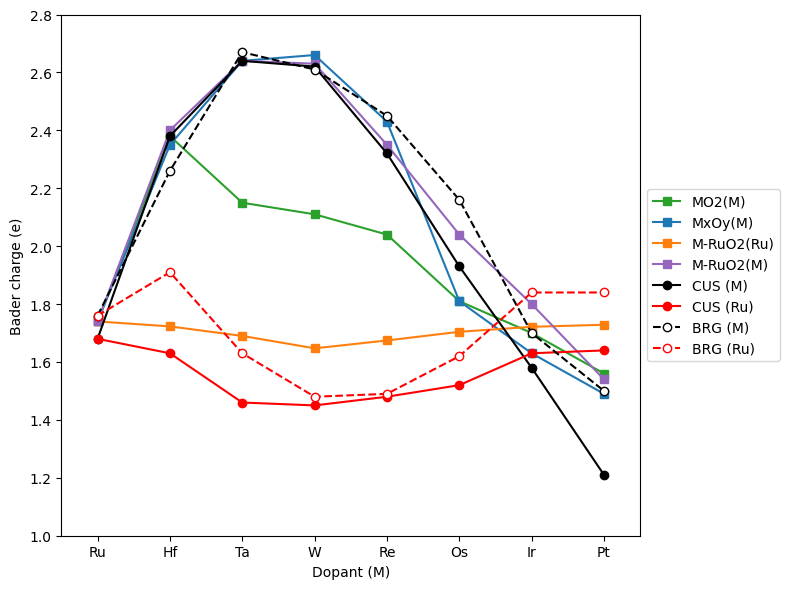

In [ ]:
plt.figure(figsize=(8,6))

plt.plot(elements, data['MO2(M)'][0:8], linestyle='-', marker='s', label='MO2(M)', color='tab:green')
plt.plot(elements, data['MxOy(M)'][0:8], linestyle='-', marker='s', label='MxOy(M)', color='tab:blue')
plt.plot(elements, data['M-RuO2(Ru)'][0:8], linestyle='-', marker='s', label='M-RuO2(Ru)', color='tab:orange')
plt.plot(elements, data['M-RuO2(M)'][0:8], linestyle='-', marker='s', label='M-RuO2(M)', color='tab:purple')
plt.plot(elements, data['M15'][0:8], linestyle='-', marker='o', label='CUS (M)', color='black')
plt.plot(elements, data['M14'][0:8], linestyle='-', marker='o', label='CUS (Ru)', color='red')
plt.plot(elements, data['M15'][8:16], linestyle='--', marker='o', label='BRG (M)', color='black', markerfacecolor='white')
plt.plot(elements, data['M12'][8:16], linestyle='--', marker='o', label='BRG (Ru)', color='red', markerfacecolor='white')

plt.xlabel('Dopant (M)')
plt.ylabel('Bader charge (e)')
plt.ylim(1.0, 2.8)

plt.xlim(-0.5, 7.5)
plt.xticks(range(len(elements)), elements)
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

plt.savefig(f'{root}/figures/bader_charge_per_atom2.png', dpi=dpi, transparent=True, bbox_inches='tight')
plt.tight_layout()
plt.show()
plt.close()

In [ ]:
# plt.figure(figsize=(8,6))

# plt.plot(elements, data['MO2(O)'][0:8], linestyle='-', marker='s', label='MO2(O)', color='tab:green')
# plt.plot(elements, data['MxOy(O)'][0:8], linestyle='-', marker='s', label='MxOy(O)', color='tab:blue')
# plt.plot(elements, data['M-RuO2(O)'][0:8], linestyle='-', marker='s', label='M-RuO2(O)', color='tab:orange')
# plt.plot(elements, data['O39'][0:8], linestyle='-', marker='o', label='CUS (Oz)', color='black')
# plt.plot(elements, data['O45'][0:8], linestyle='-', marker='o', label='CUS (Oxy)', color='red')
# plt.plot(elements, data['O43'][8:16], linestyle='--', marker='o', label='BRG (Oz)', color='black', markerfacecolor='white')
# plt.plot(elements, data['O47'][8:16], linestyle='--', marker='o', label='BRG (Oxy)', color='red', markerfacecolor='white')

# plt.xlabel('Dopant (M)')
# plt.ylabel('Bader charge (e)')
# plt.ylim(-1.3, -0.6)

# plt.xlim(-0.5, 7.5)
# plt.xticks(range(len(elements)), elements)
# plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))

# plt.savefig(f'{root}/figures/bader_charge_per_atom2.png', dpi=dpi, transparent=True, bbox_inches='tight')
# plt.tight_layout()
# plt.show()
# plt.close()